In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

# Data Loading and Cleaning

### Deals

In [2]:
deals_raw = pd.read_csv("../data/NBA_deals_history - deals.csv")
deals_raw.head(5)

,Player,Pos,Team Signed With,Age At Signing,Start,End,Yrs,Value,AAV
0,Jayson Tatum,PF,BOS BOS,26,2025,2029.0,5.0,"$313,933,410","$62,786,682"
1,Jaylen Brown,SF,BOS BOS,26,2024,2028.0,5.0,"$285,393,640","$57,078,728"
2,Nikola Jokic,C,DEN DEN,27,2023,2027.0,5.0,"$276,122,630","$55,224,526"
3,Shai Gilgeous-Alexander,PG,OKC OKC,26,2027,2030.0,4.0,"$273,302,400","$68,325,600"
4,Evan Mobley,PF,CLE CLE,23,2025,2029.0,5.0,"$269,085,780","$53,817,156"


In [3]:
# Rename weirdly formatted column names
deals_raw.rename(columns={'Age                     At Signing': 'Age'}, inplace=True)
deals_raw.rename(columns={'Team                     Signed With': 'Team'}, inplace=True)

# Fix datatypes
deals_raw['Value'] = (deals_raw['Value'].replace('[\$,]', '', regex=True).astype('Int64'))
deals_raw['AAV'] = (deals_raw['AAV'].replace('[\$,]', '', regex=True).astype('Int64'))
deals_raw['Age'] = (deals_raw['Age'].replace('[\,]', '', regex=True).astype('Int64'))

In [4]:
deals_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9286 entries, 0 to 9285
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  9286 non-null   object 
 1   Pos     9286 non-null   object 
 2   Team    9286 non-null   object 
 3   Age     9031 non-null   Int64  
 4   Start   9286 non-null   int64  
 5   End     9280 non-null   float64
 6   Yrs     9271 non-null   float64
 7   Value   8353 non-null   Int64  
 8   AAV     8352 non-null   Int64  
dtypes: Int64(3), float64(2), int64(1), object(3)
memory usage: 680.3+ KB


In [5]:
# Exclude 2025-start contracts from training — those use 2024-25 stats as input,
# which is the same data we predict on. Holding them out avoids data leakage
# and lets us validate predictions against real contracts after the fact.
standard_deals_only = deals_raw[
    (deals_raw['Yrs'] < 10) &
    (deals_raw['Value'] > 1000000) &
    (deals_raw['Start'] < 2025)
]

In [6]:
standard_deals = standard_deals_only

In [7]:
deals_nulls = standard_deals.isnull().sum().sort_values(ascending=False)
deals_nulls.head(9)

Age       123
Player      0
Pos         0
Team        0
Start       0
End         0
Yrs         0
Value       0
AAV         0
dtype: int64

In [8]:
# Replace missing age values with league median
standard_deals['Age'] = standard_deals['Age'].fillna(standard_deals['Age'].median())

# Check that nulls are gone
deals_nulls = standard_deals.isnull().sum().sort_values(ascending=False)
deals_nulls.head(9)

/var/folders/xj/9h4bjml967jfwyry9fsh16bc0000gn/T/ipykernel_77041/2685949337.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_deals['Age'] = standard_deals['Age'].fillna(standard_deals['Age'].median())


Player    0
Pos       0
Team      0
Age       0
Start     0
End       0
Yrs       0
Value     0
AAV       0
dtype: int64

In [9]:
standard_deals = standard_deals.drop(columns=['Team'], axis=1)

In [10]:
deals = standard_deals
deals.head()

,Player,Pos,Age,Start,End,Yrs,Value,AAV
1,Jaylen Brown,SF,26,2024,2028.0,5.0,285393640,57078728
2,Nikola Jokic,C,27,2023,2027.0,5.0,276122630,55224526
6,Bradley Beal,SG,29,2022,2026.0,5.0,251019650,50203930
7,Anthony Edwards,SG,21,2024,2028.0,5.0,244623120,48924624
8,Tyrese Haliburton,PG,23,2024,2028.0,5.0,244623120,48924624


### Stats

In [11]:
stats_raw = pd.read_csv("../data/kaggle_data/nba_with_2024_25.csv")
stats_raw.drop('TEAM_ID', axis=1, inplace=True)
stats_raw.sort_values(by='PLAYER_ID', ascending=True, inplace=True)
stats_raw.head(5)

,year,Season_type,PLAYER_ID,RANK,PLAYER,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
647,2012-13,Playoffs,255,179,Grant Hill,LAC,1,20.0,2,4,0.500,0,0,0.000,0,0,0.000,2,2,4,2,0,0,1,5,4,7,2.00,0.00
384,2012-13,Regular%20Season,255,385,Grant Hill,LAC,29,437.0,38,98,0.388,3,11,0.273,14,24,0.583,6,43,49,26,11,7,25,39,93,91,1.04,0.44
429,2012-13,Regular%20Season,436,430,Juwan Howard,MIA,7,51.0,10,19,0.526,0,0,0.000,1,1,1.000,0,8,8,6,0,0,4,9,21,22,1.50,0.00
214,2012-13,Regular%20Season,467,215,Jason Kidd,NYK,76,2043.0,152,409,0.372,114,325,0.351,40,48,0.833,50,273,323,249,125,25,76,125,458,839,3.28,1.65
622,2012-13,Playoffs,467,154,Jason Kidd,NYK,12,247.0,3,25,0.120,3,17,0.176,2,2,1.000,7,35,42,24,12,4,13,12,11,58,1.85,0.92


- we have stats on seasons from 2012/13 to 2024/25
    - train on: 2012/13 - 2023/24
    - predict values for 2024/25

Change Season_type values for nicer column names after pivoting

In [12]:
stats_raw['Season_type'] = np.where(stats_raw['Season_type'] == 'Regular%20Season', 'RegularSeason', stats_raw['Season_type'])

Pivot the table so that regular and playoff stats are on the same row

In [13]:
wide = stats_raw.pivot(index=['PLAYER_ID', 'PLAYER', 'year'], columns='Season_type').sort_index()
wide.columns = [f'{stat}_{stype}' for stat, stype in wide.columns]
stats = wide.reset_index()
stats.sort_values(by='PLAYER_ID', ascending=True, inplace=True)
stats = stats.drop(columns=['RANK_Playoffs', 'RANK_RegularSeason'])
stats.head(2)

,PLAYER_ID,PLAYER,year,TEAM_Playoffs,TEAM_RegularSeason,GP_Playoffs,GP_RegularSeason,MIN_Playoffs,MIN_RegularSeason,FGM_Playoffs,FGM_RegularSeason,FGA_Playoffs,FGA_RegularSeason,FG_PCT_Playoffs,FG_PCT_RegularSeason,FG3M_Playoffs,FG3M_RegularSeason,FG3A_Playoffs,FG3A_RegularSeason,FG3_PCT_Playoffs,FG3_PCT_RegularSeason,FTM_Playoffs,FTM_RegularSeason,FTA_Playoffs,FTA_RegularSeason,FT_PCT_Playoffs,FT_PCT_RegularSeason,OREB_Playoffs,OREB_RegularSeason,DREB_Playoffs,DREB_RegularSeason,REB_Playoffs,REB_RegularSeason,AST_Playoffs,AST_RegularSeason,STL_Playoffs,STL_RegularSeason,BLK_Playoffs,BLK_RegularSeason,TOV_Playoffs,TOV_RegularSeason,PF_Playoffs,PF_RegularSeason,PTS_Playoffs,PTS_RegularSeason,EFF_Playoffs,EFF_RegularSeason,AST_TOV_Playoffs,AST_TOV_RegularSeason,STL_TOV_Playoffs,STL_TOV_RegularSeason
0,255,Grant Hill,2012-13,LAC,LAC,1.0,29.0,20.0,437.0,2.0,38.0,4.0,98.0,0.5,0.388,0.0,3.0,0.0,11.0,0.0,0.273,0.0,14.0,0.0,24.0,0.0,0.583,2.0,6.0,2.0,43.0,4.0,49.0,2.0,26.0,0.0,11.0,0.0,7.0,1.0,25.0,5.0,39.0,4.0,93.0,7.0,91.0,2.0,1.04,0.0,0.44
1,436,Juwan Howard,2012-13,NaN,MIA,NaN,7.0,NaN,51.0,NaN,10.0,NaN,19.0,NaN,0.526,NaN,0.0,NaN,0.0,NaN,0.000,NaN,1.0,NaN,1.0,NaN,1.000,NaN,0.0,NaN,8.0,NaN,8.0,NaN,6.0,NaN,0.0,NaN,0.0,NaN,4.0,NaN,9.0,NaN,21.0,NaN,22.0,NaN,1.50,NaN,0.00


### Merged

Combine our two tables, **deals** and **stats** on deals.player = stats.PLAYER and only on years where deals.start = stats.year

- Before we can do this, we need to reformat year to match the year format in deals. Since deals are signed in the summer following a season, we can just look at the year that the second half of the season happens in in our stats table. Example: 2012-13 -> 2013

In [14]:
stats["year"] = stats["year"].str.split("-").str[1].astype(int) + 2000

In [15]:
## Prepare to merge datasets
print("entries in stats: " + str(len(stats)))
print("entries in deals: " + str(len(deals)))

entries in stats: 6837
entries in deals: 5093


In [16]:
merged = pd.merge(stats, deals,
                  left_on=["PLAYER", "year"],
                  right_on=["Player", "Start"],
                  how="inner")
print("matches: " + str(len(merged)))
merged.head(5)

matches: 2149


,PLAYER_ID,PLAYER,year,TEAM_Playoffs,TEAM_RegularSeason,GP_Playoffs,GP_RegularSeason,MIN_Playoffs,MIN_RegularSeason,FGM_Playoffs,FGM_RegularSeason,FGA_Playoffs,FGA_RegularSeason,FG_PCT_Playoffs,FG_PCT_RegularSeason,FG3M_Playoffs,FG3M_RegularSeason,FG3A_Playoffs,FG3A_RegularSeason,FG3_PCT_Playoffs,FG3_PCT_RegularSeason,FTM_Playoffs,FTM_RegularSeason,FTA_Playoffs,FTA_RegularSeason,FT_PCT_Playoffs,FT_PCT_RegularSeason,OREB_Playoffs,OREB_RegularSeason,DREB_Playoffs,DREB_RegularSeason,REB_Playoffs,REB_RegularSeason,AST_Playoffs,AST_RegularSeason,STL_Playoffs,STL_RegularSeason,BLK_Playoffs,BLK_RegularSeason,TOV_Playoffs,TOV_RegularSeason,PF_Playoffs,PF_RegularSeason,PTS_Playoffs,PTS_RegularSeason,EFF_Playoffs,EFF_RegularSeason,AST_TOV_Playoffs,AST_TOV_RegularSeason,STL_TOV_Playoffs,STL_TOV_RegularSeason,Player,Pos,Age,Start,End,Yrs,Value,AAV
0,708,Kevin Garnett,2015,NaN,MIN,NaN,47.0,NaN,952.0,NaN,143.0,NaN,306.0,NaN,0.467,NaN,1.0,NaN,7.0,NaN,0.143,NaN,36.0,NaN,45.0,NaN,0.800,NaN,48.0,NaN,263.0,NaN,311.0,NaN,77.0,NaN,46.0,NaN,17.0,NaN,46.0,NaN,109.0,NaN,323.0,NaN,556.0,NaN,1.67,NaN,1.00,Kevin Garnett,PF,38,2015,2016.0,2.0,16500000,8250000
1,948,Marcus Camby,2013,NYK,NYK,3.0,24.0,3.0,250.0,1.0,17.0,1.0,53.0,1.000,0.321,0.0,0.0,0.0,0.0,0.000,0.000,0.0,8.0,0.0,19.0,0.000,0.421,1.0,24.0,1.0,56.0,2.0,80.0,0.0,14.0,0.0,7.0,0.0,14.0,1.0,15.0,1.0,28.0,2.0,42.0,3.0,95.0,0.0,0.93,0.00,0.47,Marcus Camby,C,38,2013,2013.0,1.0,1399507,1399507
2,965,Derek Fisher,2013,OKC,OKC,11.0,33.0,261.0,575.0,32.0,55.0,70.0,161.0,0.457,0.342,24.0,30.0,51.0,80.0,0.471,0.375,8.0,35.0,12.0,38.0,0.667,0.921,1.0,2.0,16.0,35.0,17.0,37.0,8.0,47.0,7.0,19.0,1.0,3.0,8.0,30.0,33.0,55.0,96.0,175.0,79.0,142.0,1.0,1.57,0.88,0.63,Derek Fisher,PG,38,2013,2013.0,1.0,1399507,1399507
3,977,Kobe Bryant,2014,NaN,LAL,NaN,6.0,NaN,177.0,NaN,31.0,NaN,73.0,NaN,0.425,NaN,3.0,NaN,16.0,NaN,0.188,NaN,18.0,NaN,21.0,NaN,0.857,NaN,2.0,NaN,24.0,NaN,26.0,NaN,38.0,NaN,7.0,NaN,1.0,NaN,34.0,NaN,9.0,NaN,83.0,NaN,76.0,NaN,1.12,NaN,0.21,Kobe Bryant,SF,35,2014,2015.0,2.0,48500000,24250000
4,979,Jermaine O'Neal,2013,NaN,PHX,NaN,55.0,NaN,1029.0,NaN,179.0,NaN,371.0,NaN,0.482,NaN,0.0,NaN,0.0,NaN,0.000,NaN,96.0,NaN,115.0,NaN,0.835,NaN,82.0,NaN,211.0,NaN,293.0,NaN,42.0,NaN,19.0,NaN,78.0,NaN,73.0,NaN,126.0,NaN,454.0,NaN,602.0,NaN,0.57,NaN,0.26,Jermaine O'Neal,C,34,2013,2013.0,1.0,2000000,2000000


In [17]:
merged['TEAM_Playoffs'] = merged['TEAM_Playoffs'].fillna('MissedPlayoffs')
data = merged.fillna(0)
data.describe().round(2)

,PLAYER_ID,year,GP_Playoffs,GP_RegularSeason,MIN_Playoffs,MIN_RegularSeason,FGM_Playoffs,FGM_RegularSeason,FGA_Playoffs,FGA_RegularSeason,FG_PCT_Playoffs,FG_PCT_RegularSeason,FG3M_Playoffs,FG3M_RegularSeason,FG3A_Playoffs,FG3A_RegularSeason,FG3_PCT_Playoffs,FG3_PCT_RegularSeason,FTM_Playoffs,FTM_RegularSeason,FTA_Playoffs,FTA_RegularSeason,FT_PCT_Playoffs,FT_PCT_RegularSeason,OREB_Playoffs,OREB_RegularSeason,DREB_Playoffs,DREB_RegularSeason,REB_Playoffs,REB_RegularSeason,AST_Playoffs,AST_RegularSeason,STL_Playoffs,STL_RegularSeason,BLK_Playoffs,BLK_RegularSeason,TOV_Playoffs,TOV_RegularSeason,PF_Playoffs,PF_RegularSeason,PTS_Playoffs,PTS_RegularSeason,EFF_Playoffs,EFF_RegularSeason,AST_TOV_Playoffs,AST_TOV_RegularSeason,STL_TOV_Playoffs,STL_TOV_RegularSeason,Age,Start,End,Yrs,Value,AAV
count,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.0,2149.00,2149.00,2149.00,2149.0,2149.0
mean,775054.35,2019.03,3.69,48.22,80.12,1062.71,12.50,171.99,27.69,371.61,0.18,0.45,3.58,45.96,10.09,127.30,0.11,0.29,5.83,73.53,7.62,95.97,0.27,0.70,3.29,45.87,10.66,147.49,13.95,193.36,7.25,102.98,2.35,33.87,1.49,21.42,4.01,58.10,7.11,88.71,34.41,463.46,38.46,534.92,0.66,1.66,0.25,0.66,27.17,2019.03,2019.19,2.03,20566067.36,6642306.14
std,726039.92,3.41,5.64,25.14,153.86,802.45,28.67,160.32,61.18,338.84,0.24,0.11,8.68,54.15,23.39,141.93,0.19,0.16,15.87,89.43,20.19,112.23,0.38,0.22,7.90,52.57,23.16,136.38,30.07,181.87,19.21,120.97,5.33,30.48,3.94,27.60,9.37,56.36,12.98,64.20,79.34,439.23,87.01,482.30,1.19,1.02,0.50,0.49,4.1,3.41,39.38,1.19,38576368.18,8974806.65
min,708.00,2013.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-4.00,-4.00,0.00,0.00,0.00,0.00,19.0,2013.00,202.00,1.00,1010371.0,510634.0
25%,201937.00,2016.00,0.00,26.00,0.00,312.00,0.00,38.00,0.00,87.00,0.00,0.40,0.00,2.00,0.00,10.00,0.00,0.23,0.00,12.00,0.00,17.00,0.00,0.66,0.00,10.00,0.00,37.00,0.00,50.00,0.00,19.00,0.00,8.00,0.00,4.00,0.00,14.00,0.00,31.00,0.00,101.00,0.00,128.00,0.00,1.00,0.00,0.39,24.0,2016.00,2017.00,1.00,1902133.0,1640080.0
50%,203504.00,2019.00,0.00,55.00,0.00,979.00,0.00,131.00,0.00,283.00,0.00,0.44,0.00,24.00,0.00,76.00,0.00,0.33,0.00,43.00,0.00,59.00,0.00,0.76,0.00,28.00,0.00,116.00,0.00,148.00,0.00,65.00,0.00,27.00,0.00,12.00,0.00,45.00,0.00,87.00,0.00,342.00,0.00,435.00,0.00,1.55,0.00,0.57,26.0,2019.00,2020.00,2.00,3466716.0,2500000.0
75%,1628436.00,2022.00,6.00,69.00,105.00,1690.00,12.00,259.00,30.00,559.00,0.42,0.50,2.00,75.00,7.00,210.00,0.26,0.38,4.00,99.00,6.00,129.00,0.67,0.83,3.00,61.00,11.00,215.00,15.00,280.00,5.00,137.00,2.00,50.00,1.00,29.00,4.00,84.00,10.00,135.00,35.00,693.00,38.00,805.00,1.00,2.16,0.36,0.85,30.0,2022.00,2023.00,3.00,19500000.0,8000000.0
max,1642013.00,2024.00,24.00,84.00,939.00,3125.00,275.00,857.00,544.00,1909.00,1.00,1.00,91.00,378.00,229.00,1028.00,1.00,1.00,191.00,754.00,216.00,858.00,1.00,1.00,88.00,397.00,210.00,842.00,269.00,1226.00,199.00,839.00,49.00,169.00,38.00,269.00,94.00,387.00,89.00,292.00,748.00,2818.00,816.00,2681.00,13.00,10.00,5.00,6.00,42.0,2024.00,2028.00,5.00,285393640.0,57078728.0


### Rolling Season Averages
Per-game averages over the last 2, 3, and 4 seasons for key stats. Stabilizes against one outlier season while preserving career trajectory signal. Computed from the full stats history before contract-year filtering, then merged back in.

In [18]:
rolling_stat_map = {
    'PTS': 'PTS_RegularSeason',
    'REB': 'REB_RegularSeason',
    'AST': 'AST_RegularSeason',
    'STL': 'STL_RegularSeason',
    'BLK': 'BLK_RegularSeason',
    'TOV': 'TOV_RegularSeason',
}
windows = [2, 3, 4]

# Pull only the columns we need from the full stats history (all seasons, all players)
stats_roll = stats[['PLAYER_ID', 'year', 'GP_RegularSeason'] + list(rolling_stat_map.values())].copy()

# Convert to per-game so season length / games played don't skew the average
for stat_name, col in rolling_stat_map.items():
    stats_roll[f'{stat_name}_pg'] = np.where(
        stats_roll['GP_RegularSeason'] > 0,
        stats_roll[col] / stats_roll['GP_RegularSeason'],
        np.nan  # no games played → exclude from rolling mean
    )

# Sort chronologically per player so the rolling window looks backward in time
stats_roll = stats_roll.sort_values(['PLAYER_ID', 'year']).reset_index(drop=True)

# Compute rolling means for each window
# min_periods=1 so rookies/players with fewer seasons still get a value
for window in windows:
    for stat_name in rolling_stat_map:
        col_name = f'{stat_name}_mean_{window}yr'
        stats_roll[col_name] = (
            stats_roll.groupby('PLAYER_ID')[f'{stat_name}_pg']
            .transform(lambda x, w=window: x.rolling(w, min_periods=1).mean())
        )

# Keep only the merge keys and the new rolling feature columns
roll_feature_cols = [f'{s}_mean_{w}yr' for s in rolling_stat_map for w in windows]
stats_roll_final = stats_roll[['PLAYER_ID', 'year'] + roll_feature_cols]

# Merge into data on the player + contract-signing year
data = data.merge(stats_roll_final, on=['PLAYER_ID', 'year'], how='left')

print(f"Rolling features added. Data shape: {data.shape}")
data[roll_feature_cols].describe().round(2)

Rolling features added. Data shape: (2149, 77)


,PTS_mean_2yr,PTS_mean_3yr,PTS_mean_4yr,REB_mean_2yr,REB_mean_3yr,REB_mean_4yr,AST_mean_2yr,AST_mean_3yr,AST_mean_4yr,STL_mean_2yr,STL_mean_3yr,STL_mean_4yr,BLK_mean_2yr,BLK_mean_3yr,BLK_mean_4yr,TOV_mean_2yr,TOV_mean_3yr,TOV_mean_4yr
count,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00
mean,8.12,8.17,8.15,3.48,3.50,3.49,1.82,1.83,1.82,0.61,0.62,0.62,0.39,0.39,0.39,1.06,1.07,1.08
std,5.57,5.49,5.41,2.27,2.26,2.25,1.70,1.70,1.69,0.38,0.38,0.38,0.38,0.38,0.38,0.75,0.75,0.74
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.11,4.22,4.19,1.88,1.92,1.93,0.71,0.70,0.69,0.32,0.33,0.34,0.13,0.13,0.14,0.55,0.58,0.58
50%,6.82,6.91,6.89,2.99,2.97,2.98,1.27,1.27,1.29,0.55,0.55,0.56,0.28,0.29,0.28,0.89,0.90,0.92
75%,10.75,10.79,10.72,4.57,4.62,4.60,2.33,2.34,2.34,0.83,0.82,0.84,0.53,0.53,0.53,1.36,1.39,1.39
max,33.28,31.88,31.16,14.48,14.24,14.68,10.67,10.35,10.10,2.41,2.41,2.41,3.12,3.12,3.12,5.08,5.02,4.91


# Feature Engineering

Normalize target variable from: salary -> salary as a percentage of league imposed maximum salary cap

In [19]:
salary_cap_by_year = {
    2013: 58679000,
    2014: 63065000,
    2015: 70000000,
    2016: 94143000,
    2017: 99093000,
    2018: 101869000,
    2019: 109140000,
    2020: 109140000,
    2021: 112414000,
    2022: 123655000,
    2023: 136021000,
    2024: 140588000
}

In [20]:
data['SalaryCap'] = data['year'].map(salary_cap_by_year)

In [21]:
# this is our first target variable (the other is Yrs)
data['salary_ratio'] = data['AAV'] / data['SalaryCap']

In [22]:
# sanity check
data[['Player', 'year', 'Value', 'Yrs', 'AAV', 'SalaryCap', 'salary_ratio']].describe()

,year,Value,Yrs,AAV,SalaryCap,salary_ratio
count,2149.000000,2149.0,2149.000000,2149.0,2.149000e+03,2149.0
mean,2019.027455,20566067.359702,2.026989,6642306.142392,1.051848e+08,0.064734
std,3.406874,38576368.182384,1.185031,8974806.652942,2.482145e+07,0.08273
min,2013.000000,1010371.0,1.000000,510634.0,5.867900e+07,0.007295
25%,2016.000000,1902133.0,1.000000,1640080.0,9.414300e+07,0.015383
50%,2019.000000,3466716.0,2.000000,2500000.0,1.091400e+08,0.0235
75%,2022.000000,19500000.0,3.000000,8000000.0,1.236550e+08,0.080769
max,2024.000000,285393640.0,5.000000,57078728.0,1.405880e+08,0.435392


calculate per game and per 36 min stats so model gains more context

In [23]:
reg_cats = ['MIN_RegularSeason', 'FGM_RegularSeason', 'FGA_RegularSeason','FG3M_RegularSeason','FG3A_RegularSeason', 'FTM_RegularSeason',
            'FTA_RegularSeason', 'OREB_RegularSeason','DREB_RegularSeason','REB_RegularSeason','AST_RegularSeason', 'STL_RegularSeason',
            'BLK_RegularSeason', 'TOV_RegularSeason', 'PF_RegularSeason', 'PTS_RegularSeason', 'EFF_RegularSeason']

playoff_cats = ['FGM_Playoffs', 'FGA_Playoffs', 'FG3M_Playoffs', 'FG3A_Playoffs', 'FTM_Playoffs','FTA_Playoffs', 'OREB_Playoffs',
                'DREB_Playoffs', 'REB_Playoffs',  'AST_Playoffs',  'STL_Playoffs','BLK_Playoffs', 'TOV_Playoffs', 'PF_Playoffs',
                'PTS_Playoffs',	'EFF_Playoffs']

per_game_df = pd.DataFrame(index=data.index)
per_36_df = pd.DataFrame(index=data.index)

for stat in reg_cats:
    per_game_df[f'{stat}_per_game'] = data[stat] / data['GP_RegularSeason']
    per_36_df[f'{stat}_per36'] = (data[stat] / data['MIN_RegularSeason']) * 36

for stat in playoff_cats:
    per_game_df[f'{stat}_per_game'] = data[stat] / data['GP_Playoffs']
    per_36_df[f'{stat}_per36'] = (data[stat] / data['MIN_Playoffs']) * 36


data = pd.concat([data, per_game_df, per_36_df], axis=1)

### Additional Feature Engineering

In [24]:
# 1. Age squared — salary peaks non-linearly around ages 27-29
data['Age_squared'] = data['Age'] ** 2

# 2. True Shooting % — TS% = PTS / (2 * (FGA + 0.44 * FTA))
#    Better efficiency metric than raw FG% as it accounts for 3-pointers and free throws
denom_rs = 2 * (data['FGA_RegularSeason'] + 0.44 * data['FTA_RegularSeason'])
data['TS_pct_RegularSeason'] = np.where(denom_rs > 0, data['PTS_RegularSeason'] / denom_rs, 0)

denom_po = 2 * (data['FGA_Playoffs'] + 0.44 * data['FTA_Playoffs'])
# Non-playoff players fall back to their own RS TS% — no penalty for team missing playoffs
data['TS_pct_Playoffs'] = np.where(
    data['GP_Playoffs'] > 0,
    np.where(denom_po > 0, data['PTS_Playoffs'] / denom_po, 0),
    data['TS_pct_RegularSeason']
)

# 3. Usage rate proxy (per 36 min) — share of team offense running through the player
#    USG ≈ (FGA + 0.44*FTA + TOV) / MIN * 36
data['USG_proxy_RegularSeason'] = np.where(
    data['MIN_RegularSeason'] > 0,
    (data['FGA_RegularSeason'] + 0.44 * data['FTA_RegularSeason'] + data['TOV_RegularSeason']) / data['MIN_RegularSeason'] * 36,
    0
)
# Non-playoff players fall back to their RS usage — no penalty for team missing playoffs
data['USG_proxy_Playoffs'] = np.where(
    data['GP_Playoffs'] > 0,
    np.where(
        data['MIN_Playoffs'] > 0,
        (data['FGA_Playoffs'] + 0.44 * data['FTA_Playoffs'] + data['TOV_Playoffs']) / data['MIN_Playoffs'] * 36,
        0
    ),
    data['USG_proxy_RegularSeason']
)

# 4. Box score composite — PTS + REB + AST per game (simple star-quality signal)
data['BoxComposite_RegularSeason'] = (
    data['PTS_RegularSeason_per_game'] +
    data['REB_RegularSeason_per_game'] +
    data['AST_RegularSeason_per_game']
)
# Non-playoff players get their RS composite — not punished for team missing playoffs
data['BoxComposite_Playoffs'] = np.where(
    data['GP_Playoffs'] > 0,
    data['PTS_Playoffs_per_game'] + data['REB_Playoffs_per_game'] + data['AST_Playoffs_per_game'],
    data['BoxComposite_RegularSeason']
)

# 5. Playoff performance uplift — captures players who elevate in high-stakes games
#    Non-playoff players get 0 (neutral — no reward or penalty for team missing playoffs)
data['PTS_uplift'] = np.where(
    data['GP_Playoffs'] > 0,
    data['PTS_Playoffs_per_game'] - data['PTS_RegularSeason_per_game'],
    0
)
data['REB_uplift'] = np.where(
    data['GP_Playoffs'] > 0,
    data['REB_Playoffs_per_game'] - data['REB_RegularSeason_per_game'],
    0
)
data['AST_uplift'] = np.where(
    data['GP_Playoffs'] > 0,
    data['AST_Playoffs_per_game'] - data['AST_RegularSeason_per_game'],
    0
)

# 6. Made playoffs flag — lets the model learn the value of playoff experience independently
#    Decouples team success from the individual performance features above
data['made_playoffs'] = (data['GP_Playoffs'] > 0).astype(int)

print(f"New features added. Data shape: {data.shape}")
new_cols = ['Age_squared', 'TS_pct_RegularSeason', 'TS_pct_Playoffs',
            'USG_proxy_RegularSeason', 'USG_proxy_Playoffs',
            'BoxComposite_RegularSeason', 'BoxComposite_Playoffs',
            'PTS_uplift', 'REB_uplift', 'AST_uplift', 'made_playoffs']
data[new_cols].describe().round(3)

New features added. Data shape: (2149, 156)


,Age_squared,TS_pct_RegularSeason,TS_pct_Playoffs,USG_proxy_RegularSeason,USG_proxy_Playoffs,BoxComposite_RegularSeason,BoxComposite_Playoffs,PTS_uplift,REB_uplift,AST_uplift,made_playoffs
count,2149.0,2149.000,2149.000,2149.000,2149.000,2144.000,2149.000,2144.000,2144.000,2144.000,2149.000
mean,754.764,0.536,0.514,14.989,14.704,13.269,12.101,-0.671,-0.276,-0.198,0.443
std,235.034,0.110,0.165,4.670,5.557,8.613,9.222,2.269,1.068,0.636,0.497
min,361.0,0.000,0.000,0.000,0.000,0.000,0.000,-14.727,-9.400,-5.248,0.000
25%,576.0,0.502,0.472,11.938,11.326,7.000,5.000,-1.245,-0.375,-0.297,0.000
50%,676.0,0.547,0.534,14.504,14.183,11.513,10.196,0.000,0.000,0.000,0.000
75%,900.0,0.589,0.587,17.428,17.577,17.564,16.750,0.000,0.000,0.000,1.000
max,1764.0,1.500,1.500,60.000,67.680,50.282,52.950,8.739,5.681,5.078,1.000


In [25]:
data.describe().round(2)

,PLAYER_ID,year,GP_Playoffs,GP_RegularSeason,MIN_Playoffs,MIN_RegularSeason,FGM_Playoffs,FGM_RegularSeason,FGA_Playoffs,FGA_RegularSeason,FG_PCT_Playoffs,FG_PCT_RegularSeason,FG3M_Playoffs,FG3M_RegularSeason,FG3A_Playoffs,FG3A_RegularSeason,FG3_PCT_Playoffs,FG3_PCT_RegularSeason,FTM_Playoffs,FTM_RegularSeason,FTA_Playoffs,FTA_RegularSeason,FT_PCT_Playoffs,FT_PCT_RegularSeason,OREB_Playoffs,OREB_RegularSeason,DREB_Playoffs,DREB_RegularSeason,REB_Playoffs,REB_RegularSeason,AST_Playoffs,AST_RegularSeason,STL_Playoffs,STL_RegularSeason,BLK_Playoffs,BLK_RegularSeason,TOV_Playoffs,TOV_RegularSeason,PF_Playoffs,PF_RegularSeason,PTS_Playoffs,PTS_RegularSeason,EFF_Playoffs,EFF_RegularSeason,AST_TOV_Playoffs,AST_TOV_RegularSeason,STL_TOV_Playoffs,STL_TOV_RegularSeason,Age,Start,End,Yrs,Value,AAV,PTS_mean_2yr,PTS_mean_3yr,PTS_mean_4yr,REB_mean_2yr,REB_mean_3yr,REB_mean_4yr,AST_mean_2yr,AST_mean_3yr,AST_mean_4yr,STL_mean_2yr,STL_mean_3yr,STL_mean_4yr,BLK_mean_2yr,BLK_mean_3yr,BLK_mean_4yr,TOV_mean_2yr,TOV_mean_3yr,TOV_mean_4yr,SalaryCap,salary_ratio,MIN_RegularSeason_per_game,FGM_RegularSeason_per_game,FGA_RegularSeason_per_game,FG3M_RegularSeason_per_game,FG3A_RegularSeason_per_game,FTM_RegularSeason_per_game,FTA_RegularSeason_per_game,OREB_RegularSeason_per_game,DREB_RegularSeason_per_game,REB_RegularSeason_per_game,AST_RegularSeason_per_game,STL_RegularSeason_per_game,BLK_RegularSeason_per_game,TOV_RegularSeason_per_game,PF_RegularSeason_per_game,PTS_RegularSeason_per_game,EFF_RegularSeason_per_game,FGM_Playoffs_per_game,FGA_Playoffs_per_game,FG3M_Playoffs_per_game,FG3A_Playoffs_per_game,FTM_Playoffs_per_game,FTA_Playoffs_per_game,OREB_Playoffs_per_game,DREB_Playoffs_per_game,REB_Playoffs_per_game,AST_Playoffs_per_game,STL_Playoffs_per_game,BLK_Playoffs_per_game,TOV_Playoffs_per_game,PF_Playoffs_per_game,PTS_Playoffs_per_game,EFF_Playoffs_per_game,MIN_RegularSeason_per36,FGM_RegularSeason_per36,FGA_RegularSeason_per36,FG3M_RegularSeason_per36,FG3A_RegularSeason_per36,FTM_RegularSeason_per36,FTA_RegularSeason_per36,OREB_RegularSeason_per36,DREB_RegularSeason_per36,REB_RegularSeason_per36,AST_RegularSeason_per36,STL_RegularSeason_per36,BLK_RegularSeason_per36,TOV_RegularSeason_per36,PF_RegularSeason_per36,PTS_RegularSeason_per36,EFF_RegularSeason_per36,FGM_Playoffs_per36,FGA_Playoffs_per36,FG3M_Playoffs_per36,FG3A_Playoffs_per36,FTM_Playoffs_per36,FTA_Playoffs_per36,OREB_Playoffs_per36,DREB_Playoffs_per36,REB_Playoffs_per36,AST_Playoffs_per36,STL_Playoffs_per36,BLK_Playoffs_per36,TOV_Playoffs_per36,PF_Playoffs_per36,PTS_Playoffs_per36,EFF_Playoffs_per36,Age_squared,TS_pct_RegularSeason,TS_pct_Playoffs,USG_proxy_RegularSeason,USG_proxy_Playoffs,BoxComposite_RegularSeason,BoxComposite_Playoffs,PTS_uplift,REB_uplift,AST_uplift,made_playoffs
count,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.0,2149.00,2149.00,2149.00,2149.0,2149.0,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2147.00,2.149000e+03,2149.0,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,2144.0,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,2144.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,951.00,2149.0,2149.00,2149.00,2149.00,2149.00,2144.00,2149.00,2144.00,2144.00,2144.00,2149.00
mean,775054.35,2019.03,3.69,48.22,80.12,10

normalize player stats by comparing to league average for the given season

In [26]:
cats = ['MIN_RegularSeason', 'FGM_Playoffs', 'FGM_RegularSeason', 'FGA_Playoffs', 'FGA_RegularSeason',
        'FG_PCT_Playoffs', 'FG_PCT_RegularSeason', 'FG3M_Playoffs', 'FG3M_RegularSeason', 'FG3A_Playoffs',
        'FG3A_RegularSeason', 'FG3_PCT_Playoffs', 'FG3_PCT_RegularSeason', 'FTM_Playoffs', 'FTM_RegularSeason',
        'FTA_Playoffs', 'FTA_RegularSeason', 'FT_PCT_Playoffs',	'FT_PCT_RegularSeason',	'OREB_Playoffs',
        'OREB_RegularSeason', 'DREB_Playoffs', 'DREB_RegularSeason', 'REB_Playoffs', 'REB_RegularSeason',
        'AST_Playoffs', 'AST_RegularSeason', 'STL_Playoffs', 'STL_RegularSeason', 'BLK_Playoffs',
        'BLK_RegularSeason', 'TOV_Playoffs', 'TOV_RegularSeason', 'PF_Playoffs', 'PF_RegularSeason', 
        'PTS_Playoffs','PTS_RegularSeason',	'EFF_Playoffs', 'EFF_RegularSeason', 'AST_TOV_Playoffs',
        'AST_TOV_RegularSeason', 'STL_TOV_Playoffs', 'STL_TOV_RegularSeason']

cats += data.filter(regex='(_per_game|_per36)$').columns.tolist()

league_stats = data.groupby('year')[cats].agg(['mean'])
league_stats.columns = ['_'.join(col) for col in league_stats.columns]
league_stats.head()

,MIN_RegularSeason_mean,FGM_Playoffs_mean,FGM_RegularSeason_mean,FGA_Playoffs_mean,FGA_RegularSeason_mean,FG_PCT_Playoffs_mean,FG_PCT_RegularSeason_mean,FG3M_Playoffs_mean,FG3M_RegularSeason_mean,FG3A_Playoffs_mean,FG3A_RegularSeason_mean,FG3_PCT_Playoffs_mean,FG3_PCT_RegularSeason_mean,FTM_Playoffs_mean,FTM_RegularSeason_mean,FTA_Playoffs_mean,FTA_RegularSeason_mean,FT_PCT_Playoffs_mean,FT_PCT_RegularSeason_mean,OREB_Playoffs_mean,OREB_RegularSeason_mean,DREB_Playoffs_mean,DREB_RegularSeason_mean,REB_Playoffs_mean,REB_RegularSeason_mean,AST_Playoffs_mean,AST_RegularSeason_mean,STL_Playoffs_mean,STL_RegularSeason_mean,BLK_Playoffs_mean,BLK_RegularSeason_mean,TOV_Playoffs_mean,TOV_RegularSeason_mean,PF_Playoffs_mean,PF_RegularSeason_mean,PTS_Playoffs_mean,PTS_RegularSeason_mean,EFF_Playoffs_mean,EFF_RegularSeason_mean,AST_TOV_Playoffs_mean,AST_TOV_RegularSeason_mean,STL_TOV_Playoffs_mean,STL_TOV_RegularSeason_mean,MIN_RegularSeason_per_game_mean,FGM_RegularSeason_per_game_mean,FGA_RegularSeason_per_game_mean,FG3M_RegularSeason_per_game_mean,FG3A_RegularSeason_per_game_mean,FTM_RegularSeason_per_game_mean,FTA_RegularSeason_per_game_mean,OREB_RegularSeason_per_game_mean,DREB_RegularSeason_per_game_mean,REB_RegularSeason_per_game_mean,AST_RegularSeason_per_game_mean,STL_RegularSeason_per_game_mean,BLK_RegularSeason_per_game_mean,TOV_RegularSeason_per_game_mean,PF_RegularSeason_per_game_mean,PTS_RegularSeason_per_game_mean,EFF_RegularSeason_per_game_mean,FGM_Playoffs_per_game_mean,FGA_Playoffs_per_game_mean,FG3M_Playoffs_per_game_mean,FG3A_Playoffs_per_game_mean,FTM_Playoffs_per_game_mean,FTA_Playoffs_per_game_mean,OREB_Playoffs_per_game_mean,DREB_Playoffs_per_game_mean,REB_Playoffs_per_game_mean,AST_Playoffs_per_game_mean,STL_Playoffs_per_game_mean,BLK_Playoffs_per_game_mean,TOV_Playoffs_per_game_mean,PF_Playoffs_per_game_mean,PTS_Playoffs_per_game_mean,EFF_Playoffs_per_game_mean,MIN_RegularSeason_per36_mean,FGM_RegularSeason_per36_mean,FGA_RegularSeason_per36_mean,FG3M_RegularSeason_per36_mean,FG3A_RegularSeason_per36_mean,FTM_RegularSeason_per36_mean,FTA_RegularSeason_per36_mean,OREB_RegularSeason_per36_mean,DREB_RegularSeason_per36_mean,REB_RegularSeason_per36_mean,AST_RegularSeason_per36_mean,STL_RegularSeason_per36_mean,BLK_RegularSeason_per36_mean,TOV_RegularSeason_per36_mean,PF_RegularSeason_per36_mean,PTS_RegularSeason_per36_mean,EFF_RegularSeason_per36_mean,FGM_Playoffs_per36_mean,FGA_Playoffs_per36_mean,FG3M_Playoffs_per36_mean,FG3A_Playoffs_per36_mean,FTM_Playoffs_per36_mean,FTA_Playoffs_per36_mean,OREB_Playoffs_per36_mean,DREB_Playoffs_per36_mean,REB_Playoffs_per36_mean,AST_Playoffs_per36_mean,STL_Playoffs_per36_mean,BLK_Playoffs_per36_mean,TOV_Playoffs_per36_mean,PF_Playoffs_per36_mean,PTS_Playoffs_per36_mean,EFF_Playoffs_per36_mean
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013,1247.902778,11.965278,190.083333,27.152778,424.319444,0.184750,0.430028,2.923611,42.020833,8.340278,115.847222,0.093847,0.255354,6.555556,87.861111,8.715278,116.472222,0.275507,0.704528,3.131944,50.069444,9.152778,148.534722,12.284722,198.604167,6.840278,124.930556,2.562500,43.652778,1.472222,24.826389,4.534722,72.881944,8.166667,101.104167,33.409722,510.048611,34.687500,566.333333,0.638056,1.468750,0.270278,0.626528,20.100420,2.934940,6.693074,0.654577,1.841401,1.353548,1.811258,0.860978,2.396769,3.257747,1.910702,0.678707,0.401435,1.168522,1.695413,7.878006,8.742231,2.925229,6.820722,0.729974,2.204123,1.596922,2.211396,0.732614,2.281847,3.014461,1.709906,0.652027,0.343430,1.158722,2.003327,8.177354,8.228488,36.0,4.923498,11.347574,1.070954,3.070803,2.169918,2.987588,1.735928,4.310662,6.046590,3.051408,1.154276,0.756373,2.064129,3.354224,13.087869,14.790641,4.526974,10.499199,1.123943,3.247246,2.323879,3.608933,1.850723,4.574306,6.425029,2.180810,1.078025,0.617771,1.862991,4.069742,12.501771,13.683135
2014,1381.515625,15.460938,219.890625,34.406250,485.351562,0.209883,0.4

In [27]:
data = data.merge(league_stats, on='year', how='left', validate='many_to_one')

In [28]:
ratio_cols = {}

for stat in cats:
    mean_col = f"{stat}_mean"
    ratio_col = f"{stat}_ratio"
    ratio_cols[ratio_col] = data[stat] / data[mean_col] - 1

ratios = pd.DataFrame(ratio_cols, index=data.index)

data = pd.concat([data, ratios], axis=1)

In [29]:
data = data.fillna(0)

In [30]:
data = data.astype({col: 'Int64' for col in data.select_dtypes('bool').columns})

In [31]:
data.shape

(2149, 374)

In [32]:
# No MultiIndex columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = ['_'.join(map(str, c)).strip('_') for c in data.columns]

# Ensure all model features are numeric
non_num = data.select_dtypes(exclude=['number']).columns.tolist()
if non_num:
    print("Non-numeric columns present (encode/drop before training):", non_num[:10], "...")

# Optional: verify no nested objects
has_nested = data.head(200).applymap(lambda x: isinstance(x, (pd.DataFrame, list, dict, pd.Series))).any().any()
print("Nested objects present?", has_nested)

Non-numeric columns present (encode/drop before training): ['PLAYER', 'TEAM_Playoffs', 'TEAM_RegularSeason', 'Player', 'Pos'] ...
Nested objects present? False


/var/folders/xj/9h4bjml967jfwyry9fsh16bc0000gn/T/ipykernel_77041/465256798.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  has_nested = data.head(200).applymap(lambda x: isinstance(x, (pd.DataFrame, list, dict, pd.Series))).any().any()


# Model Training and Evaluation

In [33]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.dummy import DummyRegressor
import xgboost as xgb

In [34]:
# Select features/target variable
X = data.drop(columns=['year', 'PLAYER_ID', "PLAYER", 'Player', 'Start', 'End', 'Yrs', 'Value', 'AAV', 'SalaryCap', 'salary_ratio'])
y = data['salary_ratio']

# --- Feature reduction (374 → ~150) ---

# 1. Drop per-36 columns — per-game captures the same info more intuitively
#    This also removes per36 league-normalized ratios (e.g. PTS_RegularSeason_per36_ratio)
per36_cols = X.filter(regex='_per36').columns.tolist()

# 2. Drop raw counting stat season totals and their league-normalized ratio equivalents
#    These are dominated by games/minutes played; the per-game versions are strictly better
#    e.g. PTS_RegularSeason (total points) → drop | PTS_RegularSeason_per_game → keep
#    e.g. PTS_RegularSeason_ratio (total vs league) → drop | PTS_RegularSeason_per_game_ratio → keep
counting_stats = [
    'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA',
    'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'EFF', 'MIN'
]
seasons = ['RegularSeason', 'Playoffs']
raw_total_cols = [
    col for col in X.columns
    if any(col in (f'{s}_{t}', f'{s}_{t}_ratio') for s in counting_stats for t in seasons)
]

cols_to_drop = list(set(per36_cols + raw_total_cols))
X = X.drop(columns=cols_to_drop)

X = pd.get_dummies(X, columns=['Pos', 'TEAM_Playoffs', 'TEAM_RegularSeason'], drop_first=True)
X = X.astype({col: 'Int64' for col in X.select_dtypes('bool').columns})

print(f"Features after reduction: {X.shape[1]} (down from 374)")
print(f"\nDropped {len(cols_to_drop)} columns:")
print(f"  - {len(per36_cols)} per-36 columns")
print(f"  - {len(raw_total_cols)} raw counting totals and their ratio equivalents")
X.columns

Features after reduction: 261 (down from 374)

Dropped 166 columns:
  - 99 per-36 columns
  - 67 raw counting totals and their ratio equivalents


Index(['GP_Playoffs', 'GP_RegularSeason', 'FG_PCT_Playoffs',
       'FG_PCT_RegularSeason', 'FG3_PCT_Playoffs', 'FG3_PCT_RegularSeason',
       'FT_PCT_Playoffs', 'FT_PCT_RegularSeason', 'AST_TOV_Playoffs',
       'AST_TOV_RegularSeason',
       ...
       'TEAM_RegularSeason_OKC', 'TEAM_RegularSeason_ORL',
       'TEAM_RegularSeason_PHI', 'TEAM_RegularSeason_PHX',
       'TEAM_RegularSeason_POR', 'TEAM_RegularSeason_SAC',
       'TEAM_RegularSeason_SAS', 'TEAM_RegularSeason_TOR',
       'TEAM_RegularSeason_UTA', 'TEAM_RegularSeason_WAS'],
      dtype='object', length=261)

In [35]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X_train.dtypes.value_counts()

float64    191
Int64       69
int64        1
Name: count, dtype: int64

In [37]:
# establish models
models = {
    "MeanBaseline": DummyRegressor(strategy="mean"),
    "MedianBaseline": DummyRegressor(strategy="median"),
    "LinearRegression": LinearRegression(),
    "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 7)),
    "Lasso": LassoCV(cv=5, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=100, max_depth=None, random_state=42, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
}

In [38]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
display(results_df)

/opt/anaconda3/envs/ds-local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.001941391980101237, tolerance: 0.0008806613459212873
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ds-local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.042e-03, tolerance: 1.187e-03
  model = cd_fast.enet_coordinate_descent(


,Model,R2,RMSE,MAE
6,XGBoost,0.812673,0.035100,0.021150
5,RandomForest,0.793480,0.036854,0.022066
3,Ridge,0.781201,0.037934,0.027038
2,LinearRegression,0.774796,0.038485,0.027418
4,Lasso,0.756816,0.039992,0.028420
0,MeanBaseline,-0.000002,0.081098,0.058822
1,MedianBaseline,-0.257396,0.090938,0.048691


XGBoost outperforms other models in all evaluation metrics

Cheat Sheet:
- R2: Higher = Better
- RMSE: Lower = Better
- MAE: Lower = Better

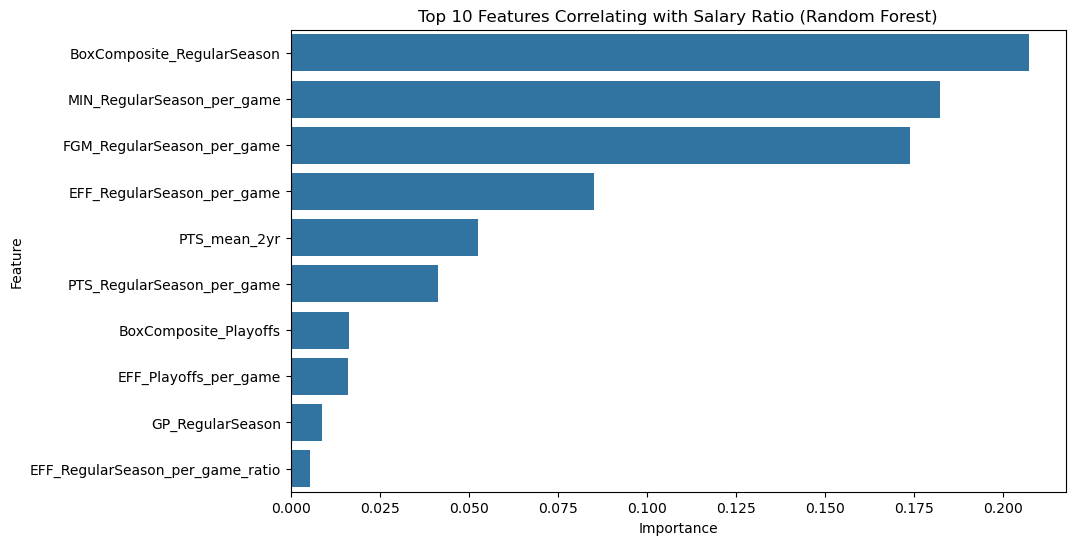

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: feature importance from RandomForest
rf = models["RandomForest"]
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.head(10), y=feat_imp.head(10).index)
plt.title("Top 10 Features Correlating with Salary Ratio (Random Forest)")
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

## Cross Validation

In [40]:
results_cv = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=7, scoring="r2", n_jobs=-1)
    results_cv.append({
        "Model": name,
        "Mean_R2": np.mean(scores),
        "Std_R2": np.std(scores),
        "Scores": scores
    })

cv_results_df = pd.DataFrame(results_cv).sort_values(by="Mean_R2", ascending=False)
display(cv_results_df)

/opt/anaconda3/envs/ds-local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0012202313447602364, tolerance: 0.0009592982861439107
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ds-local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0020480494225822987, tolerance: 0.0008836877326830724
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ds-local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0016045949619138966, tolerance: 0.0009592982861439107
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ds-local

,Model,Mean_R2,Std_R2,Scores
5,RandomForest,0.769614,0.053909,"[0.6590799613601432, 0.7568862347204135, 0.768..."
6,XGBoost,0.768924,0.055534,"[0.6421148777008057, 0.7644863724708557, 0.771..."
3,Ridge,0.706714,0.081583,"[0.6262384502347985, 0.7617339654890442, 0.726..."
4,Lasso,0.697090,0.089468,"[0.6427844337089348, 0.7471177048054989, 0.709..."
2,LinearRegression,0.693055,0.093672,"[0.6107127706591329, 0.7684786157570289, 0.740..."
0,MeanBaseline,-0.151278,0.246551,"[-0.009770471426389093, -0.0976306617888314, -..."
1,MedianBaseline,-0.285791,0.174379,"[-0.35182226131309213, -0.5124485592182977, -0..."


- Random Forest outperforms XGBoost in our cross validation test...

In [41]:
folds = [5, 7, 10]
rf_scores_means, rf_scores_stds = [], []
xgb_scores_means, xgb_scores_stds = [], []

rf_model = models["RandomForest"]
xgb_model = models["XGBoost"]

for k in folds:
    cv = KFold(n_splits=k, shuffle=True, random_state=42)
    
    rf_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    
    rf_scores_means.append(rf_scores.mean())
    rf_scores_stds.append(rf_scores.std())
    xgb_scores_means.append(xgb_scores.mean())
    xgb_scores_stds.append(xgb_scores.std())

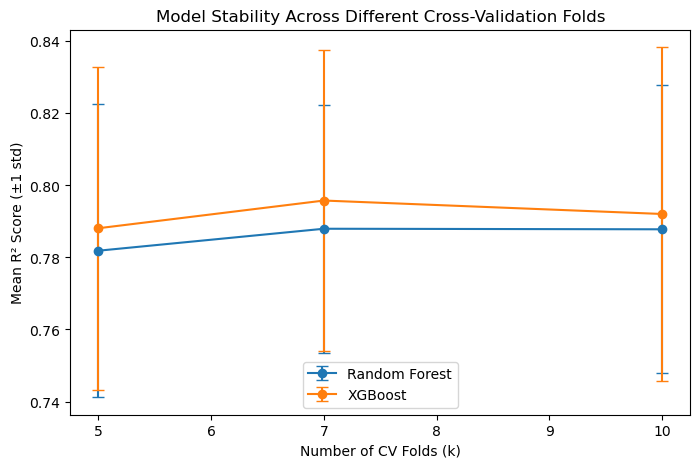

In [42]:
# Plot results
plt.figure(figsize=(8,5))
plt.errorbar(folds, rf_scores_means, yerr=rf_scores_stds, fmt='-o', label='Random Forest', capsize=4)
plt.errorbar(folds, xgb_scores_means, yerr=xgb_scores_stds, fmt='-o', label='XGBoost', capsize=4)
plt.xlabel("Number of CV Folds (k)")
plt.ylabel("Mean R² Score (±1 std)")
plt.title("Model Stability Across Different Cross-Validation Folds")
plt.legend()
plt.show()

- XGBoost is likely overfitting to our single test set, causing it perform better on our intial tests but worse when cross validation is used.
- We likely do not have enough training data for XGBoost to generalize to unseen data.

# Hyperparameter Tuning

Based on our results, we will use RandomForestRegressor as our model, as it performed the strongest on our cross-valdation testing

In [43]:
from scipy.stats import randint

# Use 5-fold instead of 7 — saves ~30% of fits with minimal accuracy tradeoff
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# n_jobs removed from base estimator to avoid thread contention with search's n_jobs=-1
rf_base = RandomForestRegressor(random_state=42)

rf_rand_space = {
    "n_estimators": randint(300, 1001),
    "max_depth": [None, 8, 10, 12, 14, 16, 18],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.5, 0.7],
    "bootstrap": [True],
    "max_samples": [None, 0.7, 0.85],
    "min_impurity_decrease": [0.0, 1e-4, 1e-3],
    "ccp_alpha": [0.0, 1e-5, 1e-4]
}

rf_rs = RandomizedSearchCV(
    rf_base, rf_rand_space, n_iter=30, scoring="r2", cv=cv5,
    n_jobs=-1, random_state=42, verbose=1, refit=True
)

rf_rs.fit(X, y)

print("RF random best R²:", rf_rs.best_score_)
print("RF random best params:", rf_rs.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RF random best R²: 0.7853688083432127
RF random best params: {'bootstrap': True, 'ccp_alpha': 1e-05, 'max_depth': 18, 'max_features': 0.5, 'max_samples': 0.85, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 380}


In [44]:
best_rf_model = rf_rs.best_estimator_

In [45]:
y_pred = best_rf_model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.025015170063177824
MAE: 0.016736551600225618


In [46]:
# Save model parameters for future use without retraining

import joblib 
print(f"joblib version: {joblib.__version__}")

joblib.dump(best_rf_model, 'NBA_salary_model.pkl')

joblib version: 1.5.1


['NBA_salary_model.pkl']